In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Load cleaned data
df = pd.read_csv('C:/data/BrandPulse-AI/data/processed/cleaned_tweets.csv')

# Drop rows with empty cleaned text
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

print(f"Dataset shape: {df.shape}")
print(f"Positive tweets: {(df['polarity']==1).sum()}")
print(f"Negative tweets: {(df['polarity']==0).sum()}")

Dataset shape: (1592958, 3)
Positive tweets: 796242
Negative tweets: 796716


In [5]:
# Split data first
X = df['cleaned_text']
y = df['polarity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} tweets")
print(f"Test set:     {X_test.shape[0]} tweets")

# Apply TF-IDF
print("\nApplying TF-IDF vectorization...")
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

# Save vectorizer
os.makedirs('C:/data/BrandPulse-AI/models', exist_ok=True)
joblib.dump(tfidf, 'C:/data/BrandPulse-AI/models/tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved ")

Training set: 1274366 tweets
Test set:     318592 tweets

Applying TF-IDF vectorization...
TF-IDF matrix shape: (1274366, 50000)
TF-IDF vectorizer saved 


In [4]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print(f"\nLogistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['Negative', 'Positive']))

# Save model
joblib.dump(lr_model, 'C:/data/BrandPulse-AI/models/logistic_model.pkl')
print("Logistic Regression model saved ")

Training Logistic Regression...

Logistic Regression Accuracy: 0.8058 (80.58%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.79      0.80    159343
    Positive       0.80      0.82      0.81    159249

    accuracy                           0.81    318592
   macro avg       0.81      0.81      0.81    318592
weighted avg       0.81      0.81      0.81    318592

Logistic Regression model saved 


In [6]:
print("Training Naive Bayes...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print(f"\nNaive Bayes Accuracy: {nb_accuracy:.4f} ({nb_accuracy*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb,
      target_names=['Negative', 'Positive']))

# Save model
joblib.dump(nb_model, 'C:/data/BrandPulse-AI/models/naive_bayes_model.pkl')
print("Naive Bayes model saved ")

Training Naive Bayes...

Naive Bayes Accuracy: 0.7860 (78.60%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.79      0.79    159343
    Positive       0.79      0.78      0.78    159249

    accuracy                           0.79    318592
   macro avg       0.79      0.79      0.79    318592
weighted avg       0.79      0.79      0.79    318592

Naive Bayes model saved 


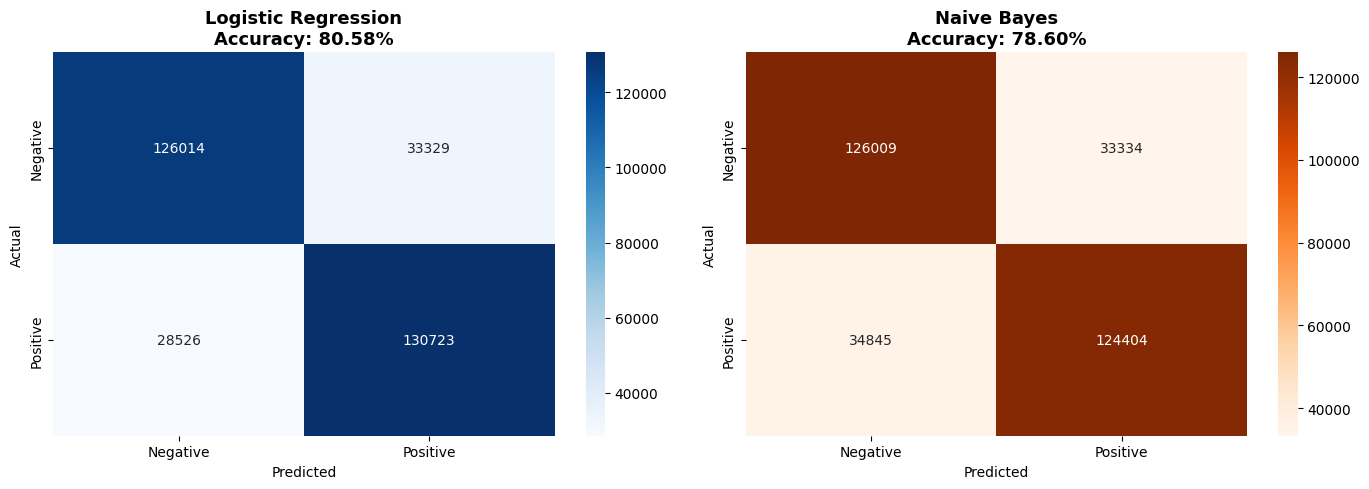

Saved confusion_matrix_classical.png 


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[1])
axes[1].set_title(f'Naive Bayes\nAccuracy: {nb_accuracy*100:.2f}%',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('C:/data/BrandPulse-AI/reports/figures/confusion_matrix_classical.png', dpi=150)
plt.show()
print("Saved confusion_matrix_classical.png ")

In [8]:
def predict_sentiment(text, model, vectorizer):
    import sys
    sys.path.append('C:/data/BrandPulse-AI')
    from src.preprocessing import clean_tweet
    cleaned = clean_tweet(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)[0]
    probability = model.predict_proba(vector)[0]
    label = 'POSITIVE 😊' if prediction == 1 else 'NEGATIVE '
    confidence = max(probability) * 100
    return label, confidence

# Test tweets
test_tweets = [
    "The service was absolutely amazing! Best experience ever!",
    "I waited 4 hours just to get a cold burger. Terrible!",
    "Not happy with my purchase. Can't believe this happened.",
    "This product changed my life. Highly recommend!",
    "Worst customer service I have ever experienced in my life."
]

print("=" * 60)
print("LOGISTIC REGRESSION PREDICTIONS")
print("=" * 60)
for tweet in test_tweets:
    label, conf = predict_sentiment(tweet, lr_model, tfidf)
    print(f"Tweet    : {tweet}")
    print(f"Predicted: {label} (confidence: {conf:.1f}%)")
    print("-" * 60)

LOGISTIC REGRESSION PREDICTIONS
Tweet    : The service was absolutely amazing! Best experience ever!
Predicted: POSITIVE 😊 (confidence: 89.7%)
------------------------------------------------------------
Tweet    : I waited 4 hours just to get a cold burger. Terrible!
Predicted: NEGATIVE 😞 (confidence: 95.5%)
------------------------------------------------------------
Tweet    : Not happy with my purchase. Can't believe this happened.
Predicted: NEGATIVE 😞 (confidence: 99.7%)
------------------------------------------------------------
Tweet    : This product changed my life. Highly recommend!
Predicted: POSITIVE 😊 (confidence: 92.3%)
------------------------------------------------------------
Tweet    : Worst customer service I have ever experienced in my life.
Predicted: NEGATIVE 😞 (confidence: 76.4%)
------------------------------------------------------------
